# Thermal Human Stress Index — Odisha Heatwave EWS
### SIH26083 · Level 2 (Daily Weather → Thermal Stress)

This notebook takes the raw NASA POWER weather data (`master_weather_odisha.csv`) and
turns it into a **daily thermal stress table per district** by computing three
recognised heat-stress indices:

| Index | Inputs used | Why we compute it |
|---|---|---|
| **Heat Index (HI)** | Max Temp, Humidity | Simple, widely known, good baseline |
| **WBGT (Wet Bulb Globe Temperature)** | Max Temp, Humidity | The index named in the problem statement; matches IMD/NDMA heatwave guidance |
| **Apparent Temperature (AT)** | Max Temp, Humidity, Wind Speed | Bonus index — makes use of wind data, shows robustness across formulas |

**Note on UTCI:** UTCI formally requires *mean radiant temperature*, which NASA POWER
doesn't give us directly. Estimating it from solar radiation would add uncertainty we can't
defend well to judges, so we're treating UTCI as a **documented future-work item** rather than
faking a number. WBGT + HI + AT together already satisfy the "WBGT/UTCI/HI" wording in the
problem statement — we just don't force UTCI with a shaky proxy.

This is **Level 2** of our two-level architecture (daily weather+thermal table).
Level 1 (the static per-district vulnerability score from health + demographic data)
gets merged onto this later, once it's built.


In [1]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.2 MB 3.0 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.2 MB 3.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.2 MB 4.2 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.2 MB 3.4 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.2 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.2 MB 3.5 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.2 MB 3.1 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 3.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 3.2 MB/s eta 0:00:01
   -----------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
WEATHER_CSV_PATH = r"C:\Users\karim\OneDrive\Desktop\Smart India Hackathon\weather\master_weather_odisha.csv"

df = pd.read_csv(WEATHER_CSV_PATH)
print(f"Loaded {len(df):,} rows, {df['district'].nunique()} districts")
df.head()


Loaded 18,265 rows, 5 districts


,YEAR,DOY,T2M_MAX,T2M_MIN,RH2M,WS10M,ALLSKY_SFC_SW_DWN,district
0,2015,1,23.39,16.88,93.18,6.80,4.29,Khordha_Bhubaneswar
1,2015,2,28.37,21.26,88.44,3.20,6.16,Khordha_Bhubaneswar
2,2015,3,28.68,19.86,82.36,1.03,13.27,Khordha_Bhubaneswar
3,2015,4,27.79,18.13,83.57,1.84,10.08,Khordha_Bhubaneswar
4,2015,5,25.25,13.95,77.59,3.20,13.72,Khordha_Bhubaneswar


## 2. Convert YEAR + DOY into a real date

NASA POWER gives dates as `YEAR` (e.g. 2015) and `DOY` (day-of-year, 1–366), not a normal
date column. We convert that to an actual `date` column so we can plot trends, extract the
month (heatwaves matter most Mar–Jun), and later merge cleanly on date.

We also compute `T2M_MEAN` (average of max/min) since POWER only gives us max and min, not
a true daily mean — this is a standard approximation used when hourly data isn't available.


In [3]:
df['date'] = pd.to_datetime(df['YEAR'].astype(str), format='%Y') + pd.to_timedelta(df['DOY'] - 1, unit='D')
df['month'] = df['date'].dt.month
df['T2M_MEAN'] = (df['T2M_MAX'] + df['T2M_MIN']) / 2

# sanity check: no missing values anywhere
print("Missing values per column:")
print(df.isna().sum())
print("\nDate range:", df['date'].min().date(), "to", df['date'].max().date())


Missing values per column:
YEAR                 0
DOY                  0
T2M_MAX              0
T2M_MIN              0
RH2M                 0
WS10M                0
ALLSKY_SFC_SW_DWN    0
district             0
date                 0
month                0
T2M_MEAN             0
dtype: int64

Date range: 2015-01-01 to 2024-12-31


## 3. Heat Index (HI)

We use the **NWS Rothfusz regression** — the standard formula the US National Weather
Service uses. It's built for Fahrenheit, so we convert in, compute, and convert back to °C.

Important detail: the full Rothfusz regression is only accurate at higher heat-stress
levels. Below that, NOAA's own guidance says to use a simpler linear formula instead —
otherwise you get unrealistic values at mild temperatures. Our function does this
switch automatically (`use_full` flag), plus applies NOAA's two small correction terms
for very dry or very humid conditions.


In [4]:
def heat_index_celsius(T_c, RH):
    """NWS Rothfusz Heat Index. Input T in Celsius, RH in %. Returns HI in Celsius."""
    T_f = T_c * 9/5 + 32
    RH = np.clip(RH, 0, 100)

    # Simple formula — used when conditions aren't hot/humid enough for the full regression
    hi_simple = 0.5 * (T_f + 61.0 + ((T_f - 68.0) * 1.2) + (RH * 0.094))

    # Decide whether the full regression is warranted (NOAA rule: avg of simple HI and T >= 80F)
    avg = (hi_simple + T_f) / 2
    use_full = avg >= 80

    hi_full = (-42.379 + 2.04901523*T_f + 10.14333127*RH
               - 0.22475541*T_f*RH - 0.00683783*T_f**2
               - 0.05481717*RH**2 + 0.00122874*T_f**2*RH
               + 0.00085282*T_f*RH**2 - 0.00000199*T_f**2*RH**2)

    # Low-humidity correction (subtracts a bit when RH<13% and T between 80-112F)
    sqrt_term = np.clip((17 - np.abs(T_f - 95.0)) / 17, 0, None)
    adj_low = ((13 - RH) / 4) * np.sqrt(sqrt_term)
    cond_low = (RH < 13) & (T_f >= 80) & (T_f <= 112)
    hi_full = np.where(cond_low, hi_full - adj_low, hi_full)

    # High-humidity correction (adds a bit when RH>85% and T between 80-87F)
    adj_high = ((RH - 85) / 10) * ((87 - T_f) / 5)
    cond_high = (RH > 85) & (T_f >= 80) & (T_f <= 87)
    hi_full = np.where(cond_high, hi_full + adj_high, hi_full)

    hi_f = np.where(use_full, hi_full, hi_simple)
    return (hi_f - 32) * 5/9

df['HI_C'] = heat_index_celsius(df['T2M_MAX'], df['RH2M'])
df['HI_C'].describe()


count    18265.000000
mean        39.335853
std         10.398931
min         17.215656
25%         30.806710
50%         39.517914
75%         45.711027
max         79.074005
Name: HI_C, dtype: float64

## 4. WBGT — Wet Bulb Globe Temperature

This is the **primary index** for our project (it's the one named first in the problem
statement, and it's what IMD/NDMA heatwave-safety guidance actually uses in India).

True WBGT needs a physical black-globe sensor reading (globe temperature), which nobody has
in a weather dataset. We use the well-known **simplified/shade approximation**
(this exact formula is published by the Australian Bureau of Meteorology and is widely used
in heat-health literature, including Indian studies, when only temperature and humidity are
available):

$$WBGT \approx 0.567 \times T + 0.393 \times e + 3.94$$

where `e` is water vapour pressure (in hPa), derived from temperature and relative humidity
using the **Magnus formula**.

**Honest limitation to note in your report:** this approximates *shaded/outdoor* WBGT. It
doesn't fold in solar radiation or wind directly the way a true black-globe measurement
would. We keep `ALLSKY_SFC_SW_DWN` (solar radiation) in the dataset as a feature for the
ML model later — even if it's not inside the WBGT formula itself, the model can still learn
from it.


In [5]:
def vapor_pressure(T_c, RH):
    """Magnus formula: actual water vapour pressure (hPa) from temp (C) and RH (%)."""
    return (RH / 100.0) * 6.105 * np.exp(17.27 * T_c / (237.7 + T_c))

def wbgt_simple(T_c, RH):
    """Simplified/shade WBGT approximation (Australian BOM formula)."""
    e = vapor_pressure(T_c, RH)
    return 0.567 * T_c + 0.393 * e + 3.94

df['WBGT'] = wbgt_simple(df['T2M_MAX'], df['RH2M'])
df['WBGT'].describe()


count    18265.000000
mean        34.071018
std          5.111510
min         19.466192
25%         30.124307
50%         34.966103
75%         37.386586
max         50.002531
Name: WBGT, dtype: float64

## 5. Apparent Temperature (AT) — bonus index using wind

This is a second, independently published formula (also Australian BOM) that folds in
**wind speed**, which HI and our WBGT approximation don't use. Including it does two things
for the project:

1. It puts your `WS10M` (wind) column to actual use instead of leaving it idle.
2. Having HI, WBGT, and AT side by side lets you show judges that your risk assessment is
   **cross-validated across multiple published formulas**, not just one.

$$AT = T + 0.33e - 0.70 \times WS - 4.00$$


In [6]:
def apparent_temp(T_c, RH, ws):
    """Australian BOM Apparent Temperature. ws = wind speed in m/s."""
    e = vapor_pressure(T_c, RH)
    return T_c + 0.33*e - 0.70*ws - 4.00

df['AT_C'] = apparent_temp(df['T2M_MAX'], df['RH2M'], df['WS10M'])
df['AT_C'].describe()


count    18265.000000
mean        35.891367
std          6.516905
min         15.737165
25%         31.201195
50%         36.217670
75%         39.950410
max         54.925696
Name: AT_C, dtype: float64

## 6. Risk categorisation (WBGT-based)

We bucket WBGT into four risk bands, adapted from NDMA/IMD heatwave colour-coding
(Green/Yellow/Orange/Red). **These thresholds are a judgment call** — flag them clearly in
your report as an adjustable parameter, and cite NDMA's heat action plan guidance if asked.

| Band | WBGT range | Meaning |
|---|---|---|
| Green | < 27°C | Low risk |
| Yellow | 27–32°C | Moderate — caution for outdoor workers |
| Orange | 32–35°C | High — heatwave-like stress |
| Red | > 35°C | Severe/Extreme — significant mortality risk |


In [7]:
def wbgt_risk_category(wbgt):
    if wbgt < 27:
        return 'Green (Low)'
    elif wbgt < 32:
        return 'Yellow (Moderate)'
    elif wbgt < 35:
        return 'Orange (High)'
    else:
        return 'Red (Severe/Extreme)'

df['WBGT_Risk'] = df['WBGT'].apply(wbgt_risk_category)

print("Overall risk day distribution:")
print(df['WBGT_Risk'].value_counts())

print("\nRed-alert (severe) days per district:")
print(df[df['WBGT_Risk'] == 'Red (Severe/Extreme)'].groupby('district').size().sort_values(ascending=False))


Overall risk day distribution:
WBGT_Risk
Red (Severe/Extreme)    9084
Yellow (Moderate)       4008
Orange (High)           3161
Green (Low)             2012
Name: count, dtype: int64

Red-alert (severe) days per district:
district
Khordha_Bhubaneswar    2241
Balasore               2124
Sambalpur              1716
Bolangir               1544
Sundargarh             1459
dtype: int64


## 7. Quick visual sanity check

A seasonal view per district — WBGT should clearly peak in the pre-monsoon months
(April–June), which is exactly when Odisha heatwaves are known to hit. If this pattern
doesn't show up, something's wrong upstream (bad merge, wrong units, etc.) — this plot is
your quickest way to catch that.


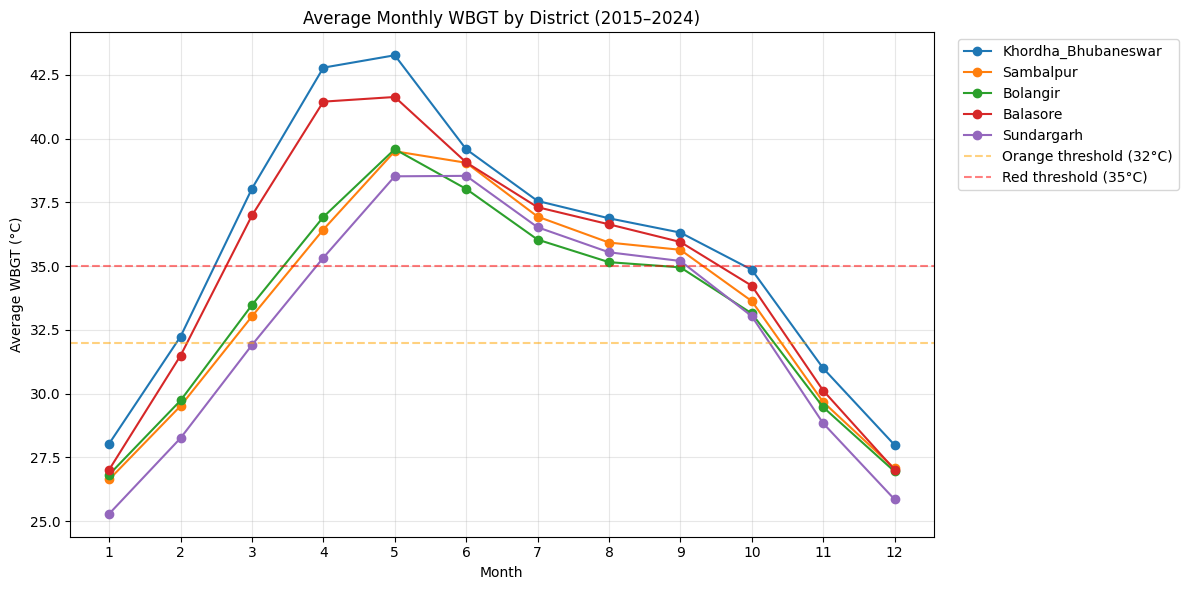

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

for district in df['district'].unique():
    monthly_avg = df[df['district'] == district].groupby('month')['WBGT'].mean()
    ax.plot(monthly_avg.index, monthly_avg.values, marker='o', label=district)

ax.axhline(32, color='orange', linestyle='--', alpha=0.5, label='Orange threshold (32°C)')
ax.axhline(35, color='red', linestyle='--', alpha=0.5, label='Red threshold (35°C)')
ax.set_xlabel('Month')
ax.set_ylabel('Average WBGT (°C)')
ax.set_title('Average Monthly WBGT by District (2015–2024)')
ax.set_xticks(range(1, 13))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Save the enriched Level 2 table

This is now a complete **Level 2 table**: daily weather + three thermal indices + a risk
category, per district. Save it back into your weather folder — Level 1 (vulnerability
score) will get merged onto this later by `district`.


In [9]:
# --- EDIT THIS PATH to your weather folder ---
OUTPUT_PATH = "../weather/master_weather_odisha_thermal.csv"

df_out = df[['district', 'date', 'YEAR', 'month', 'T2M_MAX', 'T2M_MIN', 'T2M_MEAN',
             'RH2M', 'WS10M', 'ALLSKY_SFC_SW_DWN',
             'HI_C', 'WBGT', 'AT_C', 'WBGT_Risk']]

df_out.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(df_out):,} rows to {OUTPUT_PATH}")
df_out.head()


Saved 18,265 rows to ../weather/master_weather_odisha_thermal.csv


,district,date,YEAR,month,T2M_MAX,T2M_MIN,T2M_MEAN,RH2M,WS10M,ALLSKY_SFC_SW_DWN,HI_C,WBGT,AT_C,WBGT_Risk
0,Khordha_Bhubaneswar,2015-01-01,2015,1,23.39,16.88,20.135,93.18,6.80,4.29,24.217589,27.705278,23.449437,Yellow (Moderate)
1,Khordha_Bhubaneswar,2015-01-02,2015,1,28.37,21.26,24.815,88.44,3.20,6.16,34.779658,33.405628,33.364978,Orange (High)
2,Khordha_Bhubaneswar,2015-01-03,2015,1,28.68,19.86,24.270,82.36,1.03,13.27,34.337394,32.887312,34.611158,Orange (High)
3,Khordha_Bhubaneswar,2015-01-04,2015,1,27.79,18.13,22.960,83.57,1.84,10.08,32.096535,31.920956,32.766449,Yellow (Moderate)
4,Khordha_Bhubaneswar,2015-01-05,2015,1,25.25,13.95,19.600,77.59,3.20,13.72,25.856517,28.031450,27.217763,Yellow (Moderate)
